<a href="https://colab.research.google.com/github/nozanin-13/ML-Begin/blob/main/%D0%9F%D1%80%D0%BE%D0%B5%D0%BA%D1%82_17_18_%D0%A0%D0%B0%D0%B4%D0%B0%D1%80_%D0%BE%D1%82%D0%B7%D1%8B%D0%B2%D0%BE%D0%B2_%D0%A3%D0%A7%D0%95%D0%9D%D0%98%D0%9A_150826.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛰️ Проект: «Радар отзывов»
### Финал фазы 4 · уроки 17–18 · пишем сами, получаем работающий сайт

**Задача из жизни.** Магазин получает тысячи отзывов в день. Прочитать всё вручную — недели. Сегодня ты построишь **умный анализатор тональности** и в конце — **веб-приложение с публичной ссылкой**, которое можно открыть на телефоне и показать друзьям и родителям.

**Что соберёшь по шагам:**
1. свои данные — отзывы;
2. текст → числа (токены) — мостик к уроку 17;
3. подключишь готовую модель тональности (урок 18);
4. разберёшь пачку отзывов и посмотришь на уверенность модели;
5. поймаешь «хитрые» отзывы, где модель может ошибиться;
6. нарисуешь диаграмму позитив/негатив;
7. ⭐ завернёшь всё в веб-приложение (Gradio) с публичной ссылкой.

> Запускай в Google Colab: **Среда выполнения → Выполнить все**. Ячейки выполняй сверху вниз.

---
**Как работать:** там, где стоит `# TODO`, код пишешь ты сам. Рядом — подсказка и «✅ Проверка», что должно получиться. Не подсматривай в решение сразу — сначала попробуй.

## Шаг 1 · Твои данные
Хороший анализ начинается со своих данных. Собери отзывы о том, что тебе близко.

In [9]:
отзывы = [
    # TODO: впиши сюда 8 своих отзывов, каждый в кавычках через запятую
    'Эта игра затягивает на часы, обожаю её!',
    'Здесь ужасная еда',
    'best place in our city',
    'unussually moments',
    'грандиозное шоу',
    'неуважительный персонал '
    'international schoool',
    'nikhav vikhen khaoy',
    'изумительное имя',
    'new spiderman on movies right now'
    # <- замени
]
print('Всего отзывов:', len(отзывы))

Всего отзывов: 9


> ✅ **Проверка.** В выводе — «Всего отзывов: 8» (или сколько ты вписал).

## Шаг 2 · Текст → числа
Модель не видит букв. Как в уроке 17: сначала текст режется на токены-числа.

In [12]:
# Шаг 2. Текст -> числа (как в уроке 17). Смотрим, на какие токены режется отзыв.
!pip install tiktoken -q
import tiktoken
enc = tiktoken.get_encoding('cl100k_base')   # токенайзер ChatGPT

пример = отзывы[3]
числа = enc.encode(пример)
куски = [enc.decode([t]) for t in числа]
print('Отзыв :', пример)
print('Токены:', куски)

Отзыв : unussually moments
Токены: ['un', 'uss', 'ually', ' moments']


> ✅ **Проверка.** Ты видишь, что один отзыв разбит на кусочки-токены — некоторые короче слова.

## Шаг 3 · Готовая модель
Одна строка — и у тебя модель тональности. Ничего обучать не надо (урок 18).

In [13]:
# Шаг 3. Подключаем готовую модель тональности (Hugging Face, без ключа).
!pip install transformers -q
from transformers import pipeline

# TODO: создай модель. Подсказка: pipeline('sentiment-analysis', model='nlptown/bert-base-multilingual-uncased-sentiment')
модель =pipeline('sentiment-analysis', model='nlptown/bert-base-multilingual-uncased-sentiment')

print(модель('Отличный сервис!'))   # проверка: вернёт что-то вроде [{'label': '5 stars', 'score': 0.7}]

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  669MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[{'label': '5 stars', 'score': 0.664527416229248}]


> ✅ **Проверка.** Вывод вроде `[{'label': '5 stars', 'score': ...}]`. Модель загрузилась.

🔶 **Усложни (для сильных):** добавь вторую, англоязычную модель и сравни ответы на один русский отзыв.

## Шаг 4 · Понятный вердикт
Модель отвечает «звёздами». Превратим их в ПОЗИТИВ / НЕГАТИВ / НЕЙТРАЛ + уверенность.

In [15]:

# Шаг 4. Превращаем ответ модели ('4 stars', 0.8) в понятный вердикт.
def разобрать(отзыв):
    р = модель(отзыв)[0]
    звёзд = int(р['label'][0])        # '4 stars' -> 4
    увер  = р['score']                # уверенность 0..1
    # TODO: верни вердикт по звёздам:
    #   4-5 -> 'ПОЗИТИВ', 1-2 -> 'НЕГАТИВ', иначе 'НЕЙТРАЛ'
    if звёзд >= 4:
        вердикт = 'ПОЗИТИВ'
    elif звёзд <= 2:
        вердикт = 'НЕГАТИВ'
    else:
        вердикт = 'НЕЙТРАЛ'
    return звёзд, вердикт, увер

print(разобрать('Лучшее кафе в городе!'))

(5, 'ПОЗИТИВ', 0.896060049533844)


> ✅ **Проверка.** Для «Лучшее кафе в городе!» вердикт — ПОЗИТИВ.

## Шаг 5 · Пачка отзывов
Прогоняем все свои отзывы и считаем, чего больше.

In [16]:
# Шаг 5. Прогоняем ВСЕ свои отзывы и считаем позитив/негатив/нейтрал.
счёт = {'ПОЗИТИВ':0, 'НЕГАТИВ':0, 'НЕЙТРАЛ':0}
for о in отзывы:
    звёзд, вердикт, увер = разобрать(о)
    # TODO: увеличь счётчик нужного вердикта на 1. Подсказка: счёт[вердикт] += 1

    print(f'{вердикт:8} {звёзд}★  ув.{увер:.0%}  <-  {о}')
print('\nИтог:', счёт)

ПОЗИТИВ  5★  ув.53%  <-  Эта игра затягивает на часы, обожаю её!
ПОЗИТИВ  5★  ув.48%  <-  Здесь ужасная еда
ПОЗИТИВ  5★  ув.90%  <-  best place in our city
ПОЗИТИВ  5★  ув.27%  <-  unussually moments
ПОЗИТИВ  5★  ув.82%  <-  грандиозное шоу
НЕГАТИВ  1★  ув.48%  <-  неуважительный персонал international schoool
НЕГАТИВ  1★  ув.26%  <-  nikhav vikhen khaoy
ПОЗИТИВ  5★  ув.60%  <-  изумительное имя
ПОЗИТИВ  5★  ув.56%  <-  new spiderman on movies right now

Итог: {'ПОЗИТИВ': 0, 'НЕГАТИВ': 0, 'НЕЙТРАЛ': 0}


> ✅ **Проверка.** Каждый отзыв получил вердикт и уверенность, а в конце — словарь с числами.

## Шаг 6 · Хитрые случаи
Сарказм и «не плохо» модель путает. Помечаем спорные — это работа умного инженера.

In [17]:
# Шаг 6. Ловим ХИТРЫЕ отзывы (сарказм, «не плохо»): низкая уверенность или нейтрал.
print('На проверку человеку:')
for о in отзывы:
    звёзд, вердикт, увер = разобрать(о)
    # TODO: если увер < 0.6 ИЛИ вердикт == 'НЕЙТРАЛ' — напечатай этот отзыв
    # Подсказка: if увер < 0.6 or вердикт == 'НЕЙТРАЛ':
    pass

На проверку человеку:


> ✅ **Проверка.** В список попали сарказм и отзывы с «не» — там модель менее уверена.

🔶 **Усложни (для сильных):** добавь свой список слов-маркеров сарказма (кавычки, «спасибо, что…») и помечай их отдельно.

## Шаг 7 · Диаграмма
Показываем результат наглядно — столбики позитив/негатив/нейтрал.

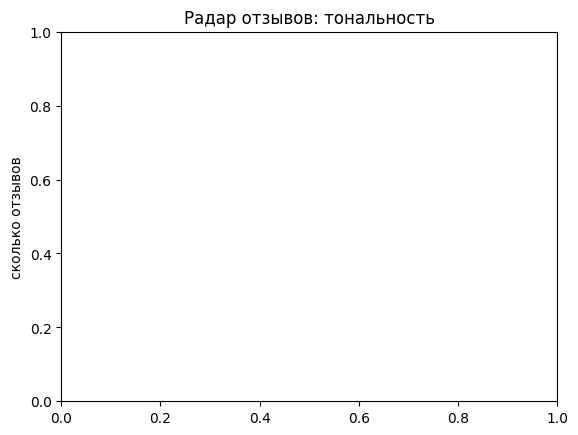

In [18]:
# Шаг 7. Рисуем диаграмму — видно результат работы твоего анализатора!
import matplotlib.pyplot as plt
метки  = list(счёт.keys())
числа_ = list(счёт.values())
# TODO: построй столбчатую диаграмму. Подсказка: plt.bar(метки, числа_, color=['#2DD4BF','#FF7A8A','#9E96C8'])

plt.title('Радар отзывов: тональность'); plt.ylabel('сколько отзывов'); plt.show()

> ✅ **Проверка.** Появилась столбчатая диаграмма с тремя столбиками.

## Шаг 8 · ⭐ Веб-приложение
Финал: заворачиваем анализатор в сайт с публичной ссылкой (Gradio).

In [22]:
# Шаг 8 ⭐. Веб-приложение! Публичная ссылка — открой на телефоне, покажи родителям.
!pip install gradio -q
import gradio as gr

def оценить(отзыв):
    звёзд, вердикт, увер = разобрать(отзыв)
    флаг = '  ⚠ стоит проверить человеку' if (увер<0.6 or вердикт=='НЕЙТРАЛ') else ''
    return f'{вердикт} ({звёзд}★, уверенность {увер:.0%}){флаг}'
gr.Interface(fn=оценить, inputs='text', outputs='text',
             title='🛰️ Радар отзывов', description='Введи отзыв-модель определит тональность').launch(share=True)


# TODO: создай и запусти интерфейс. Подсказка:
# gr.Interface(fn=оценить, inputs='text', outputs='text', title='🛰️ Радар отзывов').launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b5a5f3583c5b872f3c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


> ✅ **Проверка.** Появилась ссылка вида https://...gradio.live — открой её на телефоне!

🔶 **Усложни (для сильных):** добавь примеры отзывов кнопками (gr.Interface(..., examples=[...])) и задеплой на Hugging Face Spaces.

## 🏁 Готово! Что у тебя получилось

Ты собрал **работающий продукт**: он читает отзыв и говорит тональность, честно помечает спорные случаи, рисует диаграмму и живёт как сайт по публичной ссылке. Это уже не «ещё один чат-бот» — это твой инструмент.

**Как оценивается мини-проект (10 баллов):**

| Критерий | Баллы |
|---|---|
| Свои данные и постановка (8 отзывов) | 2 |
| Модель подключена и разбирает отзывы | 3 |
| Диаграмма построена | 2 |
| Интерпретация: нашёл, где модель ошиблась, и объяснил почему | 3 |

**Защита (1 минута):** покажи ссылку, введи хитрый отзыв (сарказм) и объясни, почему модель сомневается.